In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
import cv2

In [5]:
cropped_images_folder = "./cropped"

In [6]:
os.listdir(cropped_images_folder)

['Atif_Aslam', 'Bhola_Record', 'Humayun_Saeed', 'Imran_Khan', 'Waqar_Zaqa']

In [7]:
celeb_dict = {}
for folders in os.scandir(cropped_images_folder):
    celebs = folders.name
    celeb_dict[celebs] =  []
    for files in os.scandir(folders.path):
        celeb_dict[celebs].append(files.path)

In [5]:
for key, value in celeb_dict.items():
    print(f"{key}: {len(value)} images")
    

Atif_Aslam: 31 images
Bhola_Record: 17 images
Humayun_Saeed: 50 images
Imran_Khan: 39 images
Waqar_Zaqa: 34 images


In [6]:

def wavelet_transform(img, mode='haar', level=1):
    imArray = img
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    imArray =  np.float32(imArray)   
    imArray /= 255;

    coeffs=pywt.wavedec2(imArray, mode, level=level)

    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;


    imArray_H=pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

In [7]:
img = celeb_dict['Bhola_Record'][13]
img = cv2.imread(img)

In [8]:
tr = wavelet_transform(img,'db1',5)

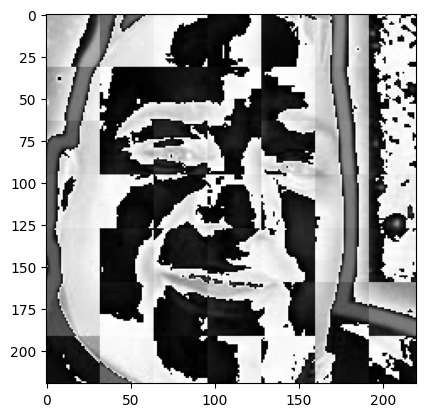

In [9]:
plt.imshow(tr,cmap='gray')

In [8]:
class_dict = {}
count = 0
for celebrity_name in celeb_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'Atif_Aslam': 0,
 'Bhola_Record': 1,
 'Humayun_Saeed': 2,
 'Imran_Khan': 3,
 'Waqar_Zaqa': 4}

In [11]:
X, y = [], []
for celebrity_name, training_files in celeb_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = wavelet_transform(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])  

In [12]:
len(X[0]),len(y)

(4096, 171)

In [13]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(171, 4096)

In [24]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report , confusion_matrix
import joblib
import seaborn as sns

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'linear', C = 1))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.8269230769230769

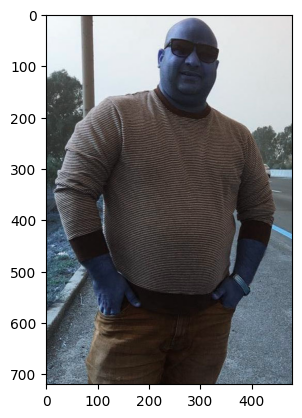

In [71]:
image = cv2.imread('./dataset/Bhola_Record/000005.jpg')
plt.imshow(image, cmap='gray')

In [72]:
def predict_image(image):
    scalled_raw_img = cv2.resize(image, (32, 32))
    img_har = wavelet_transform(image,'db1',5)
    scalled_img_har = cv2.resize(img_har, (32, 32))
    combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
    
    val = pipe.predict(combined_img.reshape(1,-1))
    for key, value in class_dict.items():
        if val == value:
            return key

In [73]:
predict_image(image)

'Bhola_Record'

In [37]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.75      0.75      0.75         4
           2       0.64      0.75      0.69        12
           3       1.00      0.92      0.96        13
           4       0.73      0.73      0.73        11

    accuracy                           0.83        52
   macro avg       0.82      0.81      0.82        52
weighted avg       0.84      0.83      0.83        52



In [38]:
matrix = confusion_matrix(y_test, pipe.predict(X_test))

<Axes: >

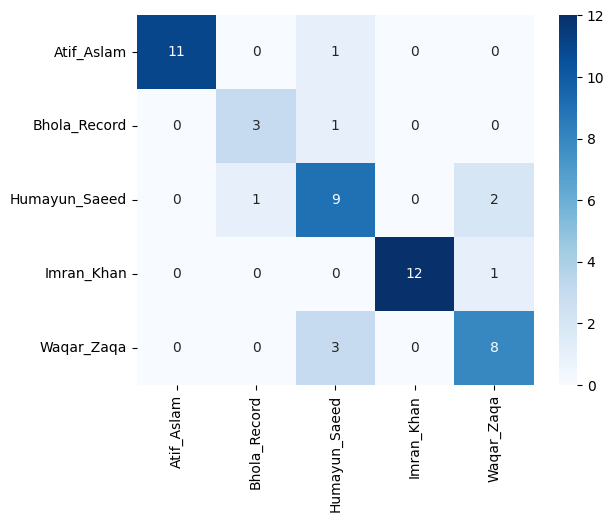

In [39]:
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_dict.keys(), yticklabels=class_dict.keys())

In [74]:
joblib.dump(pipe, 'celebrity_recognition_model.pkl')

['celebrity_recognition_model.pkl']

In [9]:
import json
with open('class_dict.json', 'w') as f:
    json.dump(class_dict, f)